In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/Data/SF_Crime/

Police_Department_Incident_Reports__Historical_2003_to_May_2018_20251224.csv


In [3]:
!pip install -q pyspark


In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("SF_Crime_Analysis") \
    .getOrCreate()

spark


In [5]:
DATA_PATH = "/content/drive/MyDrive/Data/SF_Crime/Police_Department_Incident_Reports__Historical_2003_to_May_2018_20251224.csv"

df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(DATA_PATH)
)

df.printSchema()
df.show(5)


root
 |-- PdId: long (nullable = true)
 |-- IncidntNum: integer (nullable = true)
 |-- Incident Code: integer (nullable = true)
 |-- Category: string (nullable = true)
 |-- Descript: string (nullable = true)
 |-- DayOfWeek: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- PdDistrict: string (nullable = true)
 |-- Resolution: string (nullable = true)
 |-- Address: string (nullable = true)
 |-- X: double (nullable = true)
 |-- Y: double (nullable = true)
 |-- location: string (nullable = true)
 |-- data_loaded_at: string (nullable = true)

+--------------+----------+-------------+-------------+-----------------+---------+----------+-------------------+----------+----------+--------------------+----------------+--------------+--------------------+--------------------+
|          PdId|IncidntNum|Incident Code|     Category|         Descript|DayOfWeek|      Date|               Time|PdDistrict|Resolution|             Address|           

In [6]:
df_opt1  =spark.read.format("csv").option("header","true").load(DATA_PATH)
df_opt1.show(10,truncate=False)
df_opt1.createOrReplaceTempView("sf_crime")

+--------------+----------+-------------+--------------+-----------------+---------+----------+-----+----------+-------------+-----------------------+----------------+--------------+-----------------------------------+----------------------+
|PdId          |IncidntNum|Incident Code|Category      |Descript         |DayOfWeek|Date      |Time |PdDistrict|Resolution   |Address                |X               |Y             |location                           |data_loaded_at        |
+--------------+----------+-------------+--------------+-----------------+---------+----------+-----+----------+-------------+-----------------------+----------------+--------------+-----------------------------------+----------------------+
|16020415607021|160204156 |07021        |VEHICLE THEFT |STOLEN AUTOMOBILE|Thursday |03/03/2016|19:30|TARAVAL   |NONE         |100 Block of BEPLER ST |-122.46354501682|37.70796836451|POINT (-122.463545017 37.707968365)|2025/06/20 12:17:56 PM|
|11049313327195|110493133 |27195

# Q1:
Write a spark programme to count the crimes of different cates  
多少抢劫？多少偷车？等等

In [7]:
spark_sql_ql = spark.sql("SELECT category, COUNT(*) AS Count FROM sf_crime GROUP BY category ORDER BY Count DESC")
spark_sql_ql.show(10,truncate=False)

+--------------+------+
|category      |Count |
+--------------+------+
|LARCENY/THEFT |477975|
|OTHER OFFENSES|301874|
|NON-CRIMINAL  |179139|
|ASSAULT       |167042|
|VEHICLE THEFT |126228|
|DRUG/NARCOTIC |117821|
|VANDALISM     |114718|
|WARRANTS      |99821 |
|BURGLARY      |91067 |
|SUSPICIOUS OCC|79087 |
+--------------+------+
only showing top 10 rows


In [8]:
import pandas as pd # USE pandas in spark
crimes_pd = spark_sql_ql.toPandas()
crimes_pd.head(10)

,category,Count
0,LARCENY/THEFT,477975
1,OTHER OFFENSES,301874
2,NON-CRIMINAL,179139
3,ASSAULT,167042
4,VEHICLE THEFT,126228
5,DRUG/NARCOTIC,117821
6,VANDALISM,114718
7,WARRANTS,99821
8,BURGLARY,91067
9,SUSPICIOUS OCC,79087


# How to solve big data problems via spark?
1. use RDD
2. use DataFrame, register the RDD to a DF(recommend)
3. SQL  
三选一

# Q2:
Count the number of crimes for differnet district and visualization

In [9]:
spark_sql_q2 = spark.sql("SELECT PdDistrict , COUNT(*) AS Count FROM sf_crime Group BY PdDistrict ORDER BY Count DESC")
spark_sql_q2.show(truncate = False)

+----------+------+
|PdDistrict|Count |
+----------+------+
|SOUTHERN  |378453|
|MISSION   |279744|
|NORTHERN  |260013|
|CENTRAL   |216646|
|BAYVIEW   |201989|
|TENDERLOIN|180934|
|INGLESIDE |176557|
|TARAVAL   |150970|
|PARK      |116296|
|RICHMOND  |110133|
|NA        |1     |
+----------+------+



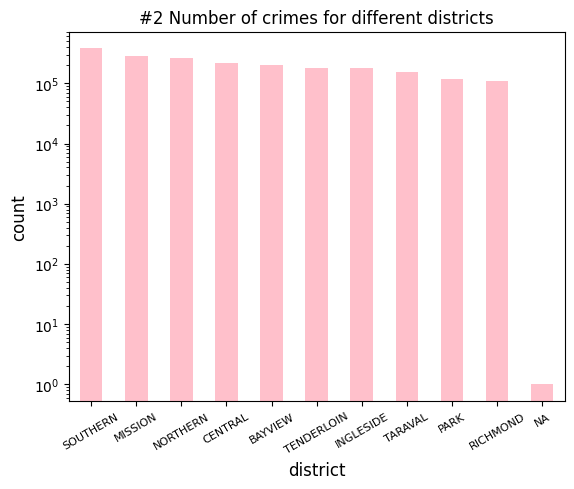

In [10]:
import matplotlib.pyplot as plt

crimes_dis_pd_df = spark_sql_q2.toPandas()

ax = crimes_dis_pd_df.plot(
    kind='bar',
    x='PdDistrict',
    y='Count',
    logy=True,
    color='pink',
    legend=False,
    align='center'
)

ax.set_ylabel('count', fontsize=12)
ax.set_xlabel('district', fontsize=12)
plt.xticks(fontsize=8, rotation=30)
plt.title('#2 Number of crimes for different districts')

plt.show()


# Q3：
Count the number of crimes each "Sunday" @ SF downtown  
hint1: downtown 经纬度定义


In [11]:
q3_result = spark.sql("""
WITH Sunday_dt_crime AS (
    SELECT
        substring(Date, 1, 5) AS Date,
        substring(Date, 7, 4) AS Year
    FROM sf_crime
    WHERE DayOfWeek = 'Sunday'
      AND CAST(X AS DOUBLE) > -122.423671
      AND CAST(X AS DOUBLE) < -122.412497
      AND CAST(Y AS DOUBLE) >  37.773510
      AND CAST(Y AS DOUBLE) <  37.782137
)
SELECT
    Year,
    Date,
    COUNT(*) AS Count
FROM Sunday_dt_crime
GROUP BY Year, Date
ORDER BY Year, Date
""")

q3_result.show(20, truncate=False)


+----+-----+-----+
|Year|Date |Count|
+----+-----+-----+
|2003|01/05|8    |
|2003|01/12|13   |
|2003|01/19|4    |
|2003|01/26|11   |
|2003|02/02|20   |
|2003|02/09|14   |
|2003|02/16|28   |
|2003|02/23|14   |
|2003|03/02|14   |
|2003|03/09|14   |
|2003|03/16|25   |
|2003|03/23|14   |
|2003|03/30|13   |
|2003|04/06|18   |
|2003|04/13|19   |
|2003|04/20|14   |
|2003|04/27|14   |
|2003|05/04|12   |
|2003|05/11|16   |
|2003|05/18|9    |
+----+-----+-----+
only showing top 20 rows


In [12]:
df_opt2 = df_opt1[['IncidntNum','Category','Descript','DayOfWeek',
                   'Date','Time','PdDistrict','Resolution',
                   'Address','X','Y','Location']]
df_opt2.createOrReplaceTempView("sf_crime")
from pyspark.sql.functions import hour, date_format, to_date, month, year
df_new = df_opt2.withColumn(
    "IncidentDate",
    to_date(df_opt2.Date, "MM/dd/yyyy")
)
df_new = df_new.withColumn("Month", month(df_new["IncidentDate"]))
df_new = df_new.withColumn("Year", year(df_new["IncidentDate"]))
df_new.show(5, truncate=False)



+----------+-------------+-----------------+---------+----------+-----+----------+----------+----------------------+----------------+--------------+-----------------------------------+------------+-----+----+
|IncidntNum|Category     |Descript         |DayOfWeek|Date      |Time |PdDistrict|Resolution|Address               |X               |Y             |Location                           |IncidentDate|Month|Year|
+----------+-------------+-----------------+---------+----------+-----+----------+----------+----------------------+----------------+--------------+-----------------------------------+------------+-----+----+
|160204156 |VEHICLE THEFT|STOLEN AUTOMOBILE|Thursday |03/03/2016|19:30|TARAVAL   |NONE      |100 Block of BEPLER ST|-122.46354501682|37.70796836451|POINT (-122.463545017 37.707968365)|2016-03-03  |3    |2016|
|110493133 |TRESPASS     |TRESPASSING      |Sunday   |06/19/2011|13:06|TARAVAL   |NONE      |100 Block of APTOS AV |-122.46675800516|37.7291845796 |POINT (-122.4667

In [13]:
from pyspark.sql.functions import col

sf_downtown = (
    (col("X").cast("double") > -122.4313) &
    (col("X").cast("double") < -122.4213) &
    (col("Y").cast("double") > 37.7540) &
    (col("Y").cast("double") < 37.7740)
)

spark_df_q3 = (
    df_new
    .filter((col("DayOfWeek") == "Sunday") & sf_downtown)
    .groupBy("IncidentDate")
    .count()
    .orderBy("IncidentDate")
)

spark_df_q3.show(20, truncate=False)


+------------+-----+
|IncidentDate|count|
+------------+-----+
|2003-01-05  |13   |
|2003-01-12  |20   |
|2003-01-19  |15   |
|2003-01-26  |13   |
|2003-02-02  |13   |
|2003-02-09  |22   |
|2003-02-16  |12   |
|2003-02-23  |14   |
|2003-03-02  |15   |
|2003-03-09  |8    |
|2003-03-16  |16   |
|2003-03-23  |9    |
|2003-03-30  |20   |
|2003-04-06  |7    |
|2003-04-13  |13   |
|2003-04-20  |13   |
|2003-04-27  |5    |
|2003-05-04  |9    |
|2003-05-11  |5    |
|2003-05-18  |16   |
+------------+-----+
only showing top 20 rows


# Q4
Analysis number of crimes in each month of 2015,2016,2017,2018. Then give your insights of the output results. What is the business impact for your result

In [14]:
df_opt2.createOrReplaceTempView("sf_crime")

In [15]:
spark_sql_q4 = spark.sql("""
SELECT
    SUBSTRING(Date, 1, 2) AS Month,
    SUBSTRING(Date, 7, 4) AS Year,
    COUNT(*) AS Count
FROM sf_crime
GROUP BY Year, Month
HAVING Year IN ('2015', '2016', '2017', '2018')
ORDER BY Year, Month
""")

spark_sql_q4.show(50, truncate=False)


+-----+----+-----+
|Month|Year|Count|
+-----+----+-----+
|01   |2015|12781|
|02   |2015|11504|
|03   |2015|13037|
|04   |2015|12125|
|05   |2015|12893|
|06   |2015|12490|
|07   |2015|12598|
|08   |2015|12875|
|09   |2015|12042|
|10   |2015|12282|
|11   |2015|11299|
|12   |2015|10749|
|01   |2016|12154|
|02   |2016|11394|
|03   |2016|11547|
|04   |2016|11486|
|05   |2016|11916|
|06   |2016|11305|
|07   |2016|11436|
|08   |2016|11747|
|09   |2016|11696|
|10   |2016|12548|
|11   |2016|11891|
|12   |2016|12225|
|01   |2017|12314|
|02   |2017|11398|
|03   |2017|12827|
|04   |2017|12092|
|05   |2017|12378|
|06   |2017|11795|
|07   |2017|12363|
|08   |2017|12028|
|09   |2017|11819|
|10   |2017|12630|
|11   |2017|11609|
|12   |2017|11772|
|01   |2018|11320|
|02   |2018|9287 |
|03   |2018|10042|
|04   |2018|9679 |
|05   |2018|3405 |
+-----+----+-----+



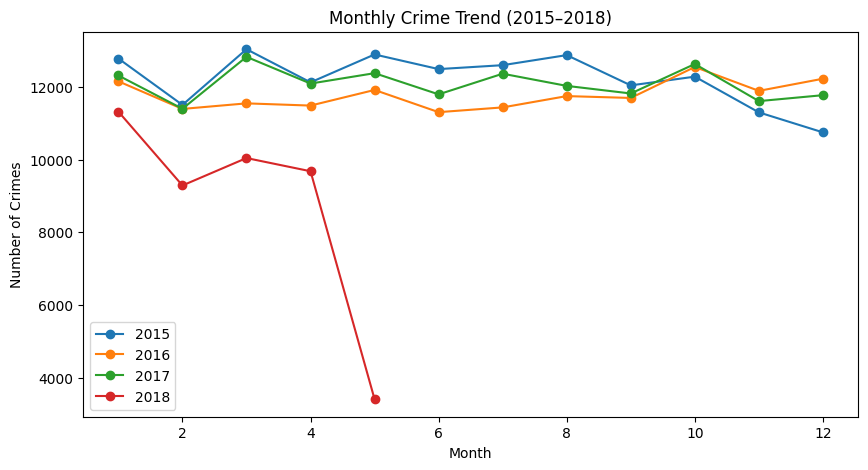

In [16]:
import matplotlib.pyplot as plt

pd_q4 = spark_sql_q4.toPandas()
pd_q4['Month'] = pd_q4['Month'].astype(int)
pd_q4['Year'] = pd_q4['Year'].astype(int)

plt.figure(figsize=(10,5))
for y in [2015, 2016, 2017, 2018]:
    temp = pd_q4[pd_q4['Year'] == y]
    plt.plot(temp['Month'], temp['Count'], marker='o', label=str(y))

plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.title("Monthly Crime Trend (2015–2018)")
plt.legend()
plt.show()


# Q5
Analysis the number of crime with respsect to the hour in certian day like 2015/12/15, 2016/12/15, 2017/12/15. Then, give your travel suggestion to visit SF.

In [17]:
# Show number of crime by hour for all records
q5_result = spark.sql("""
                      select substring(Time,1,2) as Hour,
                      count(*) as Count
                      from sf_crime
                      group by Hour
                      order by Hour
                      """)
q5_result.show(50, truncate=False)

+----+------+
|Hour|Count |
+----+------+
|00  |106869|
|01  |61748 |
|02  |51521 |
|03  |33314 |
|04  |23545 |
|05  |20976 |
|06  |31125 |
|07  |50654 |
|08  |76123 |
|09  |82997 |
|10  |88627 |
|11  |90390 |
|12  |124433|
|13  |101000|
|14  |104636|
|15  |111500|
|16  |117074|
|17  |126960|
|18  |132503|
|19  |118831|
|20  |107790|
|21  |102603|
|22  |107297|
|23  |99220 |
+----+------+



# Q6 question
(1) Step1: Find out the top-3 danger disrict 定义什么叫danger？  
(2) Step2: find out the crime event w.r.t category and time (hour) from the result of step 1  
(3) give your advice to distribute the police based on your analysis results.